In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [3]:
df = pd.read_csv('/content/train.csv', encoding='latin-1')

In [4]:
print("="*50)
print("DATASET OVERVIEW")
print('='*50)
print(f"Shape : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
print(f"DTypes : \n{df.dtypes}")
print(f"Missing values : \n{df.isnull().sum()}")
print(f"Duplicated Values : {df.duplicated().sum()}")
print(f"Basic Stats : \n{df.describe()}")

DATASET OVERVIEW
Shape : (9800, 18)
Columns : ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']
DTypes : 
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object
Missing values : 
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code     

In [5]:
print("="*50)
print("DATA CLEANING")
print("="*50)

df_clean = df.copy()

df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'], format='%d/%m/%Y')
df_clean['Ship Date'] = pd.to_datetime(df_clean['Ship Date'], format='%d/%m/%Y')

df_clean['Postal Code'] = df_clean['Postal Code'].fillna(0).astype(int)

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Removed duplicate rows : {after - before}")

DATA CLEANING
Removed duplicate rows : 0


In [6]:
Q1 = df_clean['Sales'].quantile(0.25)
Q3 = df_clean['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df_clean[(df_clean['Sales'] < lower) | (df_clean['Sales'] > upper)]

print(f"Outliers in Sales : {len(outliers)}")
print(f"Outliers % : {len(outliers)/len(df_clean)*100:.2f}%")

print(f"Clean dataset shape : {df_clean.shape}")
print("Data cleaning complete! ✅")

Outliers in Sales : 1145
Outliers % : 11.68%
Clean dataset shape : (9800, 18)
Data cleaning complete! ✅


EXPLORATORY DATA ANALYSIS


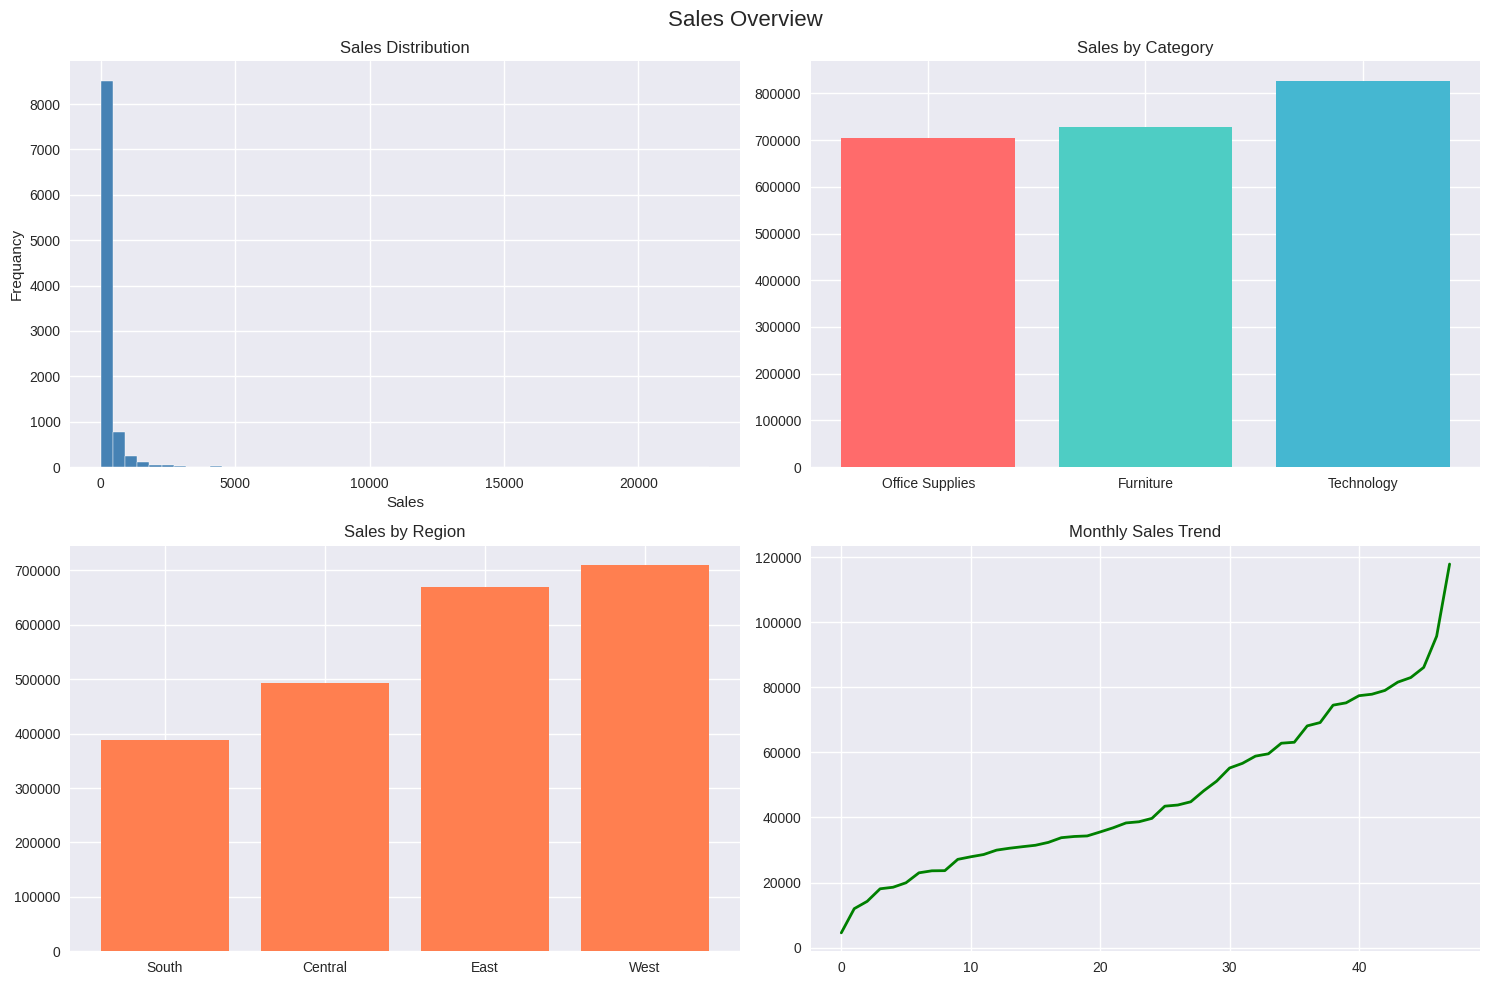

EDA plots saved! ✅


In [7]:
print('='*50)
print("EXPLORATORY DATA ANALYSIS")
print('='*50)

import os
if not os.path.exists('notebooks'):
    os.makedirs('notebooks')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Sales Overview', fontsize=16)

axes[0,0].hist(df_clean['Sales'], bins=50, color='steelblue', edgecolor='white')

axes[0,0].set_title('Sales Distribution')
axes[0,0].set_xlabel('Sales')
axes[0,0].set_ylabel('Frequancy')

cat_sales = df_clean.groupby('Category')['Sales'].sum().sort_values()

axes[0,1].bar(cat_sales.index, cat_sales.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0,1].set_title('Sales by Category')

reg_sales = df_clean.groupby('Region')['Sales'].sum().sort_values()

axes[1,0].bar(reg_sales.index, reg_sales.values, color='coral')
axes[1,0].set_title('Sales by Region')

df_clean['Month_year'] = df_clean['Order Date'].dt.to_period('M')
monthly = df_clean.groupby('Month_year')['Sales'].sum().sort_values()

axes[1,1].plot(range(len(monthly)), monthly.values, color='green', linewidth=2)
axes[1,1].set_title('Monthly Sales Trend')

plt.tight_layout()
plt.savefig('notebooks/01_overview.png', dpi=150)
plt.show()
print("EDA plots saved! ✅")